# 10.3 (iv) — Variación del tamaño del dominio

En este inciso resolvemos numéricamente la ecuación de Kuramoto–Sivashinsky para

$$
\frac{L}{2\pi}\in\{4.22,\,5,\,5.12,\,6.075,\,8\}.
$$

Siguiendo la indicación de clase usamos $N_x=64$, integramos hasta $t_f=15$ y partimos de

$$
u(x,0)=-\sin x.
$$

El objetivo no es solamente graficar $u(x,t)$: también elegiremos tres amplitudes de Fourier para cada valor de $L$ y observaremos si la trayectoria converge, oscila o desarrolla una dinámica aperiódica.

## 1. Ecuación reescaleada y representación espectral

En el dominio reescaleado $x\in[0,2\pi)$ la ecuación utilizada en los incisos anteriores es

$$
\partial_t u=-u\,\partial_xu-\partial_x^2u-k^2\partial_x^4u,
\qquad k=\frac{2\pi}{L}.
$$

Es útil introducir

$$
r=\frac{L}{2\pi}=\frac{1}{k}.
$$

Si $\widehat u_q$ es el coeficiente de Fourier del modo entero $q$, entonces

$$
\frac{d\widehat u_q}{dt}
=\left(q^2-k^2q^4\right)\widehat u_q
-\frac{iq}{2}\,\widehat{u^2}_q.
$$

La parte lineal se calcula multiplicando cada coeficiente por $q^2-k^2q^4$. La parte no lineal se evalúa pseudoespectralmente: se forma $u^2$ en el espacio físico, se aplica FFT y luego se multiplica por $-iq/2$. Para reducir aliasing aplicamos la regla de los dos tercios.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

VALORES = (4.22, 5.0, 5.12, 6.075, 8.0)
Nx = 64
tf = 15.0
dt = 1.0e-4


## 2. Integración temporal: RK2 de Heun

Para mantener la misma metodología que en los apuntes de FFT, avanzamos el **campo real** $u(x,t)$ con RK2 de Heun:

$$
K_1=F(u^n),
$$

$$
K_2=F\left(u^n+\Delta t\,K_1\right),
$$

$$
u^{n+1}=u^n+\frac{\Delta t}{2}(K_1+K_2).
$$

Aquí $F(u)$ es el lado derecho pseudoespectral. FFT/IFFT calculan las derivadas espaciales; RK2 integra en el tiempo. No son dos simulaciones diferentes, sino las dos partes del mismo algoritmo.

Avanzar directamente un arreglo de coeficientes complejos y descartar después la parte imaginaria de la IFFT puede dejar crecer errores que rompen la simetría conjugada. Por eso se actualiza $u$ como arreglo real, exactamente como en los apuntes.

In [2]:
def paso_rk2_heun(u, rhs, dt):
    k1 = rhs(u)
    k2 = rhs(u + dt*k1)
    return u + 0.5*dt*(k1 + k2)


def integrar_todos(valores=VALORES, Nx=Nx, tf=tf, dt=dt, muestras_maximas=2500):
    valores = np.asarray(valores, dtype=float)
    x = 2*np.pi*np.arange(Nx)/Nx
    q = np.fft.fftfreq(Nx, d=1.0/Nx)
    mascara = np.abs(q) <= Nx/3

    k = (1.0/valores)[:, None]
    operador_lineal = q[None, :]**2 - k**2*q[None, :]**4

    n_steps = int(np.ceil(tf/dt))
    dt = tf/n_steps
    guardar_cada = max(1, int(np.ceil(n_steps/muestras_maximas)))

    def rhs(u):
        u_hat = np.fft.fft(u, axis=1)
        u2_hat = np.fft.fft(u*u, axis=1)
        u2_hat[:, ~mascara] = 0.0

        rhs_hat = operador_lineal*u_hat - 0.5j*q[None, :]*u2_hat
        rhs_hat[:, ~mascara] = 0.0
        return np.fft.ifft(rhs_hat, axis=1).real

    u = np.repeat((-np.sin(x))[None, :], len(valores), axis=0)
    tiempos = [0.0]
    historia = [u.copy()]

    for n in range(1, n_steps + 1):
        u = paso_rk2_heun(u, rhs, dt)
        # La media es una cantidad conservada y vale cero para la CI elegida.
        u -= np.mean(u, axis=1, keepdims=True)
        if n % guardar_cada == 0 or n == n_steps:
            tiempos.append(n*dt)
            historia.append(u.copy())

    return np.asarray(tiempos), x, np.asarray(historia), dt


In [3]:
t, x, U, dt_usado = integrar_todos()
print(f"Integración terminada: dt={dt_usado:.1e}, {len(t)} instantes guardados.")
print("Forma del arreglo (tiempo, caso, espacio):", U.shape)


Integración terminada: dt=1.0e-04, 2501 instantes guardados.
Forma del arreglo (tiempo, caso, espacio): (2501, 5, 64)


## 3. Amplitudes seleccionadas

Para conservar la notación de Galerkin de los incisos anteriores definimos la amplitud seno del modo $n$ por

$$
a_n(t)=-\frac{2}{N_x}\operatorname{Im}\widehat u_n(t).
$$

En cada caso elegimos los tres modos con mayor valor RMS después del primer tercio de la simulación. La selección no se hace mirando un único instante, porque un modo puede cruzar transitoriamente por cero aunque sea dinámicamente importante.

In [4]:
def amplitudes_seno(u):
    u_hat = np.fft.fft(u, axis=1)
    return -2.0*u_hat[:, 1:Nx//3 + 1].imag/Nx


amplitudes = {}
modos_elegidos = {}
for j, r in enumerate(VALORES):
    a = amplitudes_seno(U[:, j, :])
    rms = np.sqrt(np.mean(a[len(a)//3:]**2, axis=0))
    modos = np.sort(np.argsort(rms)[-3:] + 1)
    amplitudes[r] = a
    modos_elegidos[r] = modos
    print(f"L/(2π)={r:5.3f}: modos {tuple(modos)}")


L/(2π)=4.220: modos (np.int64(3), np.int64(4), np.int64(5))
L/(2π)=5.000: modos (np.int64(1), np.int64(2), np.int64(4))
L/(2π)=5.120: modos (np.int64(3), np.int64(4), np.int64(6))
L/(2π)=6.075: modos (np.int64(4), np.int64(5), np.int64(6))
L/(2π)=8.000: modos (np.int64(4), np.int64(5), np.int64(6))


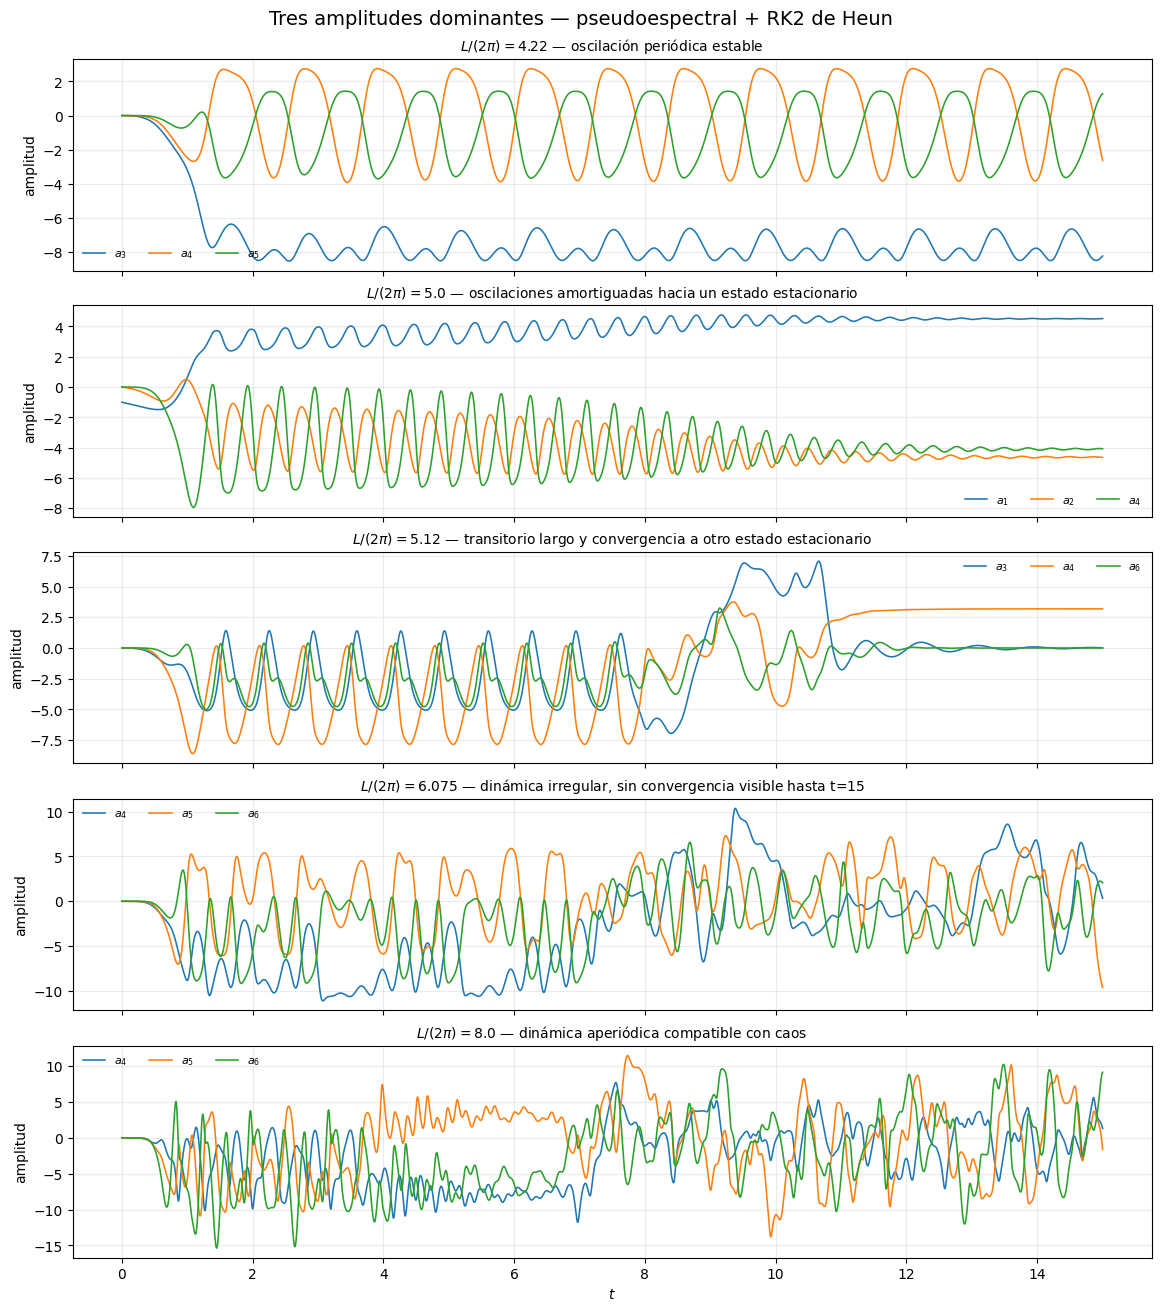

In [5]:
fig, axes = plt.subplots(5, 1, figsize=(11.5, 13), sharex=True,
                         constrained_layout=True)

descripciones = {
    4.22: "oscilación periódica estable",
    5.0: "oscilaciones amortiguadas hacia un estado estacionario",
    5.12: "transitorio largo y convergencia a otro estado estacionario",
    6.075: "dinámica irregular, sin convergencia visible hasta t=15",
    8.0: "dinámica aperiódica compatible con caos",
}

for ax, r in zip(axes, VALORES):
    a = amplitudes[r]
    for modo in modos_elegidos[r]:
        ax.plot(t, a[:, modo-1], lw=1.15, label=fr"$a_{{{modo}}}$")
    ax.set_ylabel("amplitud")
    ax.set_title(fr"$L/(2\pi)={r}$ — {descripciones[r]}", fontsize=10)
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=3, fontsize=8)

axes[-1].set_xlabel(r"$t$")
fig.suptitle("Tres amplitudes dominantes — pseudoespectral + RK2 de Heun", fontsize=14)
plt.show()


### Lectura de las series temporales

- Para $L/(2\pi)=4.22$ el transitorio cae sobre una oscilación sostenida de amplitud aproximadamente constante. Esto es compatible con un ciclo límite.
- Para $L/(2\pi)=5$ las oscilaciones disminuyen lentamente y las amplitudes se acercan a constantes: la trayectoria converge a un punto fijo.
- Para $L/(2\pi)=5.12$ aparece un transitorio oscilatorio largo, una reorganización intensa cerca de $t\simeq9$ y finalmente otro estado casi estacionario.
- Para $L/(2\pi)=6.075$ las amplitudes continúan variando irregularmente y no convergen durante el intervalo simulado.
- Para $L/(2\pi)=8$ las variaciones son aún más irregulares, con múltiples escalas temporales y sin periodicidad evidente. La evidencia numérica es compatible con caos, aunque demostrar caos rigurosamente requeriría, por ejemplo, estimar un exponente de Lyapunov positivo.

La palabra “compatible” es importante: una serie irregular y una trayectoria complicada son indicios, no una demostración matemática de caos.

## 4. Diagramas espacio–tiempo

Los mapas siguientes muestran simultáneamente la estructura espacial y su evolución. Una banda que se repite regularmente indica periodicidad; bandas que se enderezan indican convergencia a un perfil estacionario; un patrón que se reorganiza sin repetición visible indica dinámica compleja.

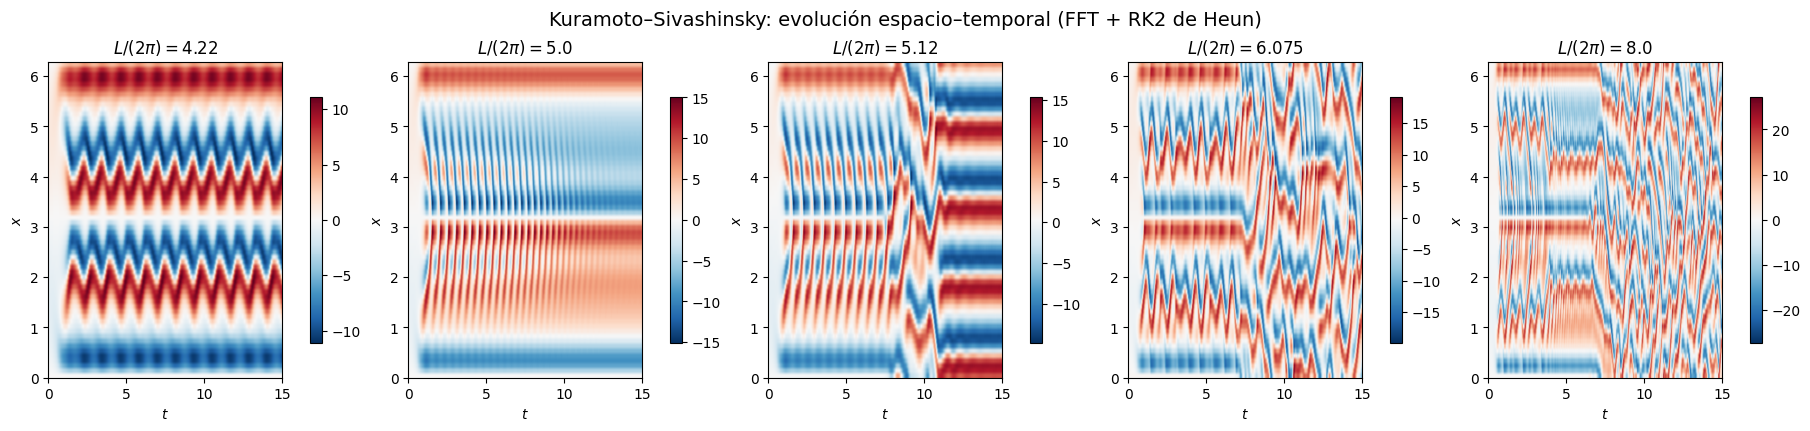

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4.2), constrained_layout=True)
for j, (ax, r) in enumerate(zip(axes, VALORES)):
    im = ax.imshow(U[:, j, :].T, origin="lower", aspect="auto",
                   extent=[t[0], t[-1], x[0], 2*np.pi], cmap="RdBu_r")
    ax.set_title(fr"$L/(2\pi)={r}$")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$x$")
    fig.colorbar(im, ax=ax, shrink=0.78)
fig.suptitle("Kuramoto–Sivashinsky: evolución espacio–temporal (FFT + RK2 de Heun)",
             fontsize=14)
plt.show()


## 5. Trayectorias en tres amplitudes

Proyectamos ahora cada solución sobre los tres modos seleccionados. Un punto fijo aparece como una trayectoria que termina en un punto; una oscilación periódica se aproxima a una curva cerrada; una órbita aperiódica ocupa una región más complicada del espacio de fases.

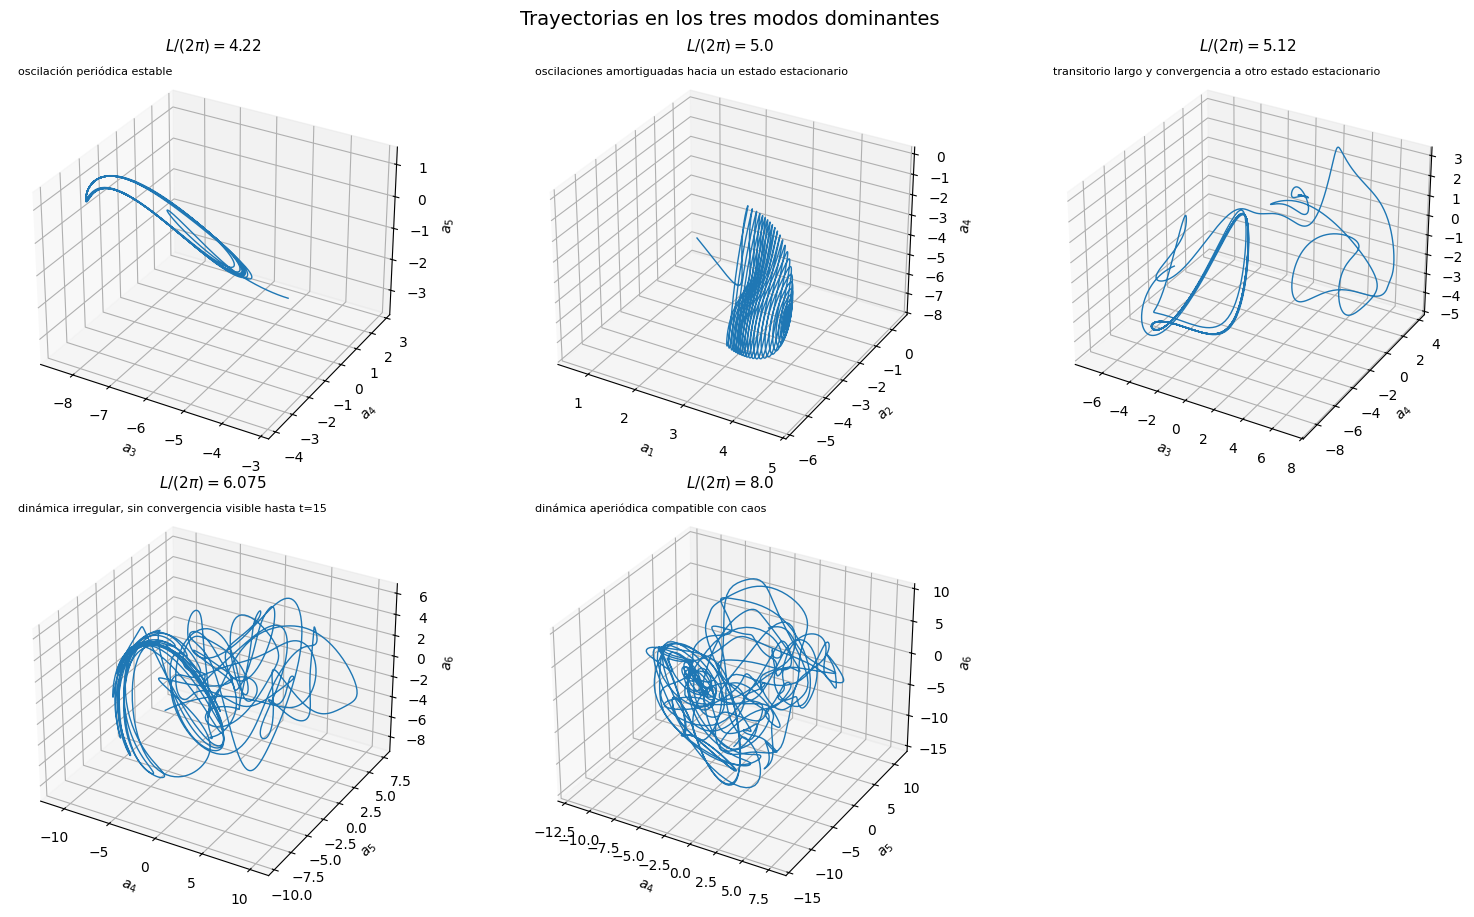

In [7]:
fig = plt.figure(figsize=(15.5, 9), constrained_layout=True)
for j, r in enumerate(VALORES):
    ax = fig.add_subplot(2, 3, j+1, projection="3d")
    a = amplitudes[r]
    m1, m2, m3 = modos_elegidos[r]
    recorte = t >= 1.0
    ax.plot(a[recorte, m1-1], a[recorte, m2-1], a[recorte, m3-1], lw=1.0)
    ax.set_xlabel(fr"$a_{{{m1}}}$")
    ax.set_ylabel(fr"$a_{{{m2}}}$")
    ax.set_zlabel(fr"$a_{{{m3}}}$")
    ax.set_title(fr"$L/(2\pi)={r}$", fontsize=11)
    ax.text2D(0.02, 0.96, descripciones[r], transform=ax.transAxes, fontsize=8)
fig.suptitle("Trayectorias en los tres modos dominantes", fontsize=14)
plt.show()


## 6. Control de estabilidad numérica

La elección de $\Delta t$ está condicionada por el modo disipativo más rígido que conserva el filtro. Para RK2 de Heun, sobre el eje real negativo, la región de estabilidad llega aproximadamente hasta

$$
-2\lesssim \lambda_q\Delta t\leq0,
$$

donde

$$
\lambda_q=q^2-k^2q^4.
$$

Con $N_x=64$ y la regla de los dos tercios, el caso más restrictivo es $L/(2\pi)=4.22$. El valor $\Delta t=10^{-4}$ queda dentro de la región estable.

Durante el desarrollo apareció además un control útil: si se avanzan los coeficientes complejos pero luego se usa solamente la parte real de la IFFT, pequeños errores pueden romper la condición de realidad

$$
\widehat u_{-q}=\widehat u_q^*.
$$

Los modos inestables amplifican esa componente espuria y producen una falsa divergencia en tiempo finito. Avanzar directamente el campo real $u$, como hacen los apuntes, mantiene la condición automáticamente y elimina esa explosión no física.

In [8]:
q = np.fft.fftfreq(Nx, d=1.0/Nx)
mascara = np.abs(q) <= Nx/3
for r in VALORES:
    lam = q**2 - (1/r)**2*q**4
    z_min = np.min(lam[mascara])*dt
    print(f"L/(2π)={r:5.3f}: min(λ_q Δt) = {z_min: .3f}")


L/(2π)=4.220: min(λ_q Δt) = -1.048
L/(2π)=5.000: min(λ_q Δt) = -0.734
L/(2π)=5.120: min(λ_q Δt) = -0.698
L/(2π)=6.075: min(λ_q Δt) = -0.483
L/(2π)=8.000: min(λ_q Δt) = -0.260


## Conclusión

Al aumentar $L$ entran más modos linealmente inestables, porque la tasa

$$
\sigma_q=q^2-k^2q^4
$$

es positiva para $0<|q|<1/k=L/(2\pi)$. Por eso la dinámica no cambia solamente de escala: aumenta el número de grados de libertad que pueden crecer y transferirse energía mediante el término no lineal.

La sucesión observada contiene oscilaciones periódicas, transitorios que terminan en estados estacionarios y, para los dominios mayores, trayectorias irregulares compatibles con dinámica caótica. Esto ilustra precisamente la transición hacia un comportamiento espacio–temporal cada vez más complejo al aumentar el tamaño del dominio.